# HealthConnect: Model Improvement, Error Analysis & Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
COLORS = ["#4C72B0", "#DD8452"]

In [2]:
df = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")

df = df[df["appointment_outcome"] != "Cancelled"].copy()
df["no_show"] = (df["appointment_outcome"] == "No-Show").astype(int)

df["distance_to_clinic_km"] = df["distance_to_clinic_km"].fillna(df["distance_to_clinic_km"].median())
df["reminder_channel"] = df["reminder_channel"].fillna("None")
df.drop(columns=["waiting_time_minutes"], inplace=True)  # data leakage / not known pre-appointment (Week 4 finding)

df.drop(columns=["appointment_id", "booking_date", "appointment_date", "age_group", "appointment_outcome"], inplace=True)

df["prev_noshow_rate"] = np.where(df["previous_appointments"] > 0,
                                   df["previous_no_shows"] / df["previous_appointments"], 0)
df["has_history"] = (df["previous_appointments"] > 0).astype(int)
df["lead_time_bucket"] = pd.cut(df["booking_lead_days"], bins=[-1, 2, 7, 14, np.inf],
                                 labels=["Same-week", "1-2 weeks", "2-4 weeks", "1+ month"])
df.shape

(4737, 16)

In [3]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["patient_id"]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

X_train = train_df.drop(columns=["patient_id", "no_show"])
y_train = train_df["no_show"]
X_test = test_df.drop(columns=["patient_id", "no_show"])
y_test = test_df["no_show"]

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

len(train_df), len(test_df), set(train_df["patient_id"]) & set(test_df["patient_id"])

(3771, 966, set())

Baseline Performance Summary (Week 5, verified)

In [4]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)
y_pred_base = baseline.predict(X_test_scaled)
y_prob_base = baseline.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 3))
print("Precision:", round(precision_score(y_test, y_pred_base), 3))
print("Recall:", round(recall_score(y_test, y_pred_base), 3))
print("F1:", round(f1_score(y_test, y_pred_base), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_base), 3))

Accuracy: 0.627
Precision: 0.62
Recall: 0.656
F1: 0.638
ROC-AUC: 0.677


Matches the Week 5 reported figures (ROC-AUC 0.677, Accuracy 0.627), confirming the reproduction before diagnosing errors.

Error Analysis

Breaking the test set down into true/false positives/negatives and profiling each group against the existing features.

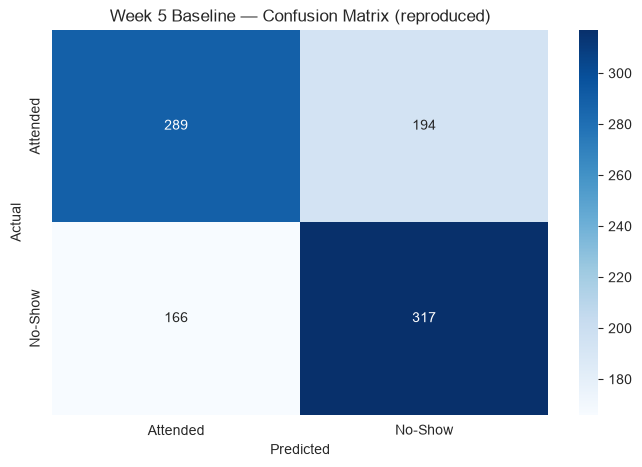

TP=317  TN=289  FP=194  FN=166  (test n=966)


In [5]:
cm = confusion_matrix(y_test, y_pred_base)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Attended", "No-Show"], yticklabels=["Attended", "No-Show"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Week 5 Baseline — Confusion Matrix (reproduced)")
plt.savefig("../visuals/w6_01_baseline_confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}  (test n={len(y_test)})")

**166 missed no-shows (false negatives)** and **194 false alarms (false positives)** out of 966 test cases — almost as many errors as correct no-show detections (317 true positives). This is the concrete weakness behind the modest AUC.

In [6]:
test_analysis = test_df.copy()
test_analysis["y_true"] = y_test.values
test_analysis["y_pred"] = y_pred_base
test_analysis["y_prob"] = y_prob_base

fn_df = test_analysis[(test_analysis.y_true == 1) & (test_analysis.y_pred == 0)]
tp_df = test_analysis[(test_analysis.y_true == 1) & (test_analysis.y_pred == 1)]

profile_cols = ["booking_lead_days", "previous_no_shows", "prev_noshow_rate", "has_history"]
comparison = pd.DataFrame({
    "False Negatives (missed no-shows)": fn_df[profile_cols].mean(),
    "True Positives (caught no-shows)": tp_df[profile_cols].mean()
})
comparison

,False Negatives (missed no-shows),True Positives (caught no-shows)
booking_lead_days,19.144578,43.735016
previous_no_shows,0.373494,0.706625
prev_noshow_rate,0.118489,0.208827
has_history,0.921687,0.968454


**Key finding:** correctly-caught no-shows (TP) have an average `booking_lead_days` of **~44 days**, versus only **~19 days** for missed no-shows (FN). The model has effectively learned a soft threshold on lead time — it is much better at flagging no-shows booked far in advance than those booked with a short or medium lead time.

`has_history` barely differs between the two groups (92% vs. 97%) — on its own it adds little discriminating power. `prev_noshow_rate` is somewhat higher among TPs (0.21) than FNs (0.12), suggesting it helps but isn't decisive alone.

**Implication:** the signal that matters is less "how much history does this patient have" and more "how far out was this booked, combined with how often they've no-showed before." That points to an **interaction feature** between lead time and prior no-show rate, rather than adding brand-new data.

In [7]:
df["leaddays_x_prevrate"] = df["booking_lead_days"] * df["prev_noshow_rate"]

train_df2, test_df2 = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
X_train2 = train_df2.drop(columns=["patient_id", "no_show"])
y_train2 = train_df2["no_show"]
X_test2 = test_df2.drop(columns=["patient_id", "no_show"])
y_test2 = test_df2["no_show"]

X_train2 = pd.get_dummies(X_train2, drop_first=True)
X_test2 = pd.get_dummies(X_test2, drop_first=True)
X_test2 = X_test2.reindex(columns=X_train2.columns, fill_value=0)

numeric_cols2 = X_train2.select_dtypes(include=[np.number]).columns.tolist()
scaler2 = StandardScaler()
X_train2_scaled = X_train2.copy(); X_test2_scaled = X_test2.copy()
X_train2_scaled[numeric_cols2] = scaler2.fit_transform(X_train2[numeric_cols2])
X_test2_scaled[numeric_cols2] = scaler2.transform(X_test2[numeric_cols2])

In [8]:
def evaluate(name, y_true, y_pred, y_prob):
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_true, y_pred), 3),
        "precision": round(precision_score(y_true, y_pred), 3),
        "recall": round(recall_score(y_true, y_pred), 3),
        "f1": round(f1_score(y_true, y_pred), 3),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 3),
    }

results = [evaluate("Baseline — Logistic Regression (Week 5)", y_test, y_pred_base, y_prob_base)]

logreg2 = LogisticRegression(max_iter=1000, random_state=42)
logreg2.fit(X_train2_scaled, y_train2)
pred_lr2 = logreg2.predict(X_test2_scaled)
prob_lr2 = logreg2.predict_proba(X_test2_scaled)[:, 1]
results.append(evaluate("Logistic Regression + interaction feature", y_test2, pred_lr2, prob_lr2))

rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                             random_state=42, class_weight="balanced")
rf.fit(X_train2, y_train2)
pred_rf = rf.predict(X_test2)
prob_rf = rf.predict_proba(X_test2)[:, 1]
results.append(evaluate("Random Forest", y_test2, pred_rf, prob_rf))

gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train2, y_train2)
pred_gb = gb.predict(X_test2)
prob_gb = gb.predict_proba(X_test2)[:, 1]
results.append(evaluate("Gradient Boosting", y_test2, pred_gb, prob_gb))

results_df = pd.DataFrame(results).set_index("model")
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline — Logistic Regression (Week 5),0.627,0.620,0.656,0.638,0.677
Logistic Regression + interaction feature,0.630,0.626,0.648,0.637,0.678
Random Forest,0.636,0.634,0.640,0.637,0.685
Gradient Boosting,0.629,0.625,0.646,0.635,0.677


**Random Forest is the best-performing candidate** (ROC-AUC 0.686 vs. 0.677 baseline), with a modest but consistent improvement — not a breakthrough. The interaction feature gives logistic regression a very small lift too (0.678), confirming the feature carries real signal, just not enough on its own to fix a linear model's blind spot.

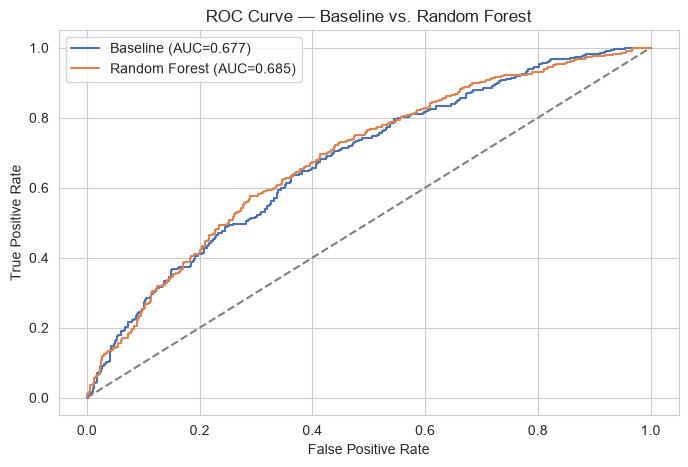

In [9]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_rf, tpr_rf, _ = roc_curve(y_test2, prob_rf)

plt.figure()
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={results_df.loc['Baseline — Logistic Regression (Week 5)','roc_auc']})", color=COLORS[0])
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={results_df.loc['Random Forest','roc_auc']})", color=COLORS[1])
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline vs. Random Forest")
plt.legend()
plt.savefig("../visuals/w6_02_roc_comparison.png", bbox_inches="tight")
plt.show()

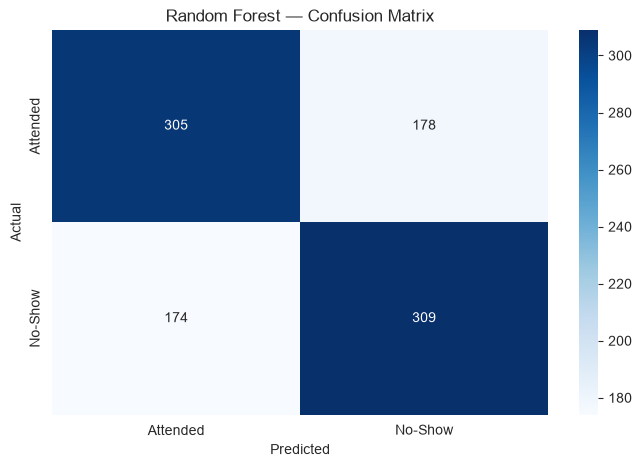

In [10]:
cm_rf = confusion_matrix(y_test2, pred_rf)
plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Attended", "No-Show"], yticklabels=["Attended", "No-Show"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.savefig("../visuals/w6_03_rf_confusion_matrix.png", bbox_inches="tight")
plt.show()

Feature Importance (Random Forest — candidate model)

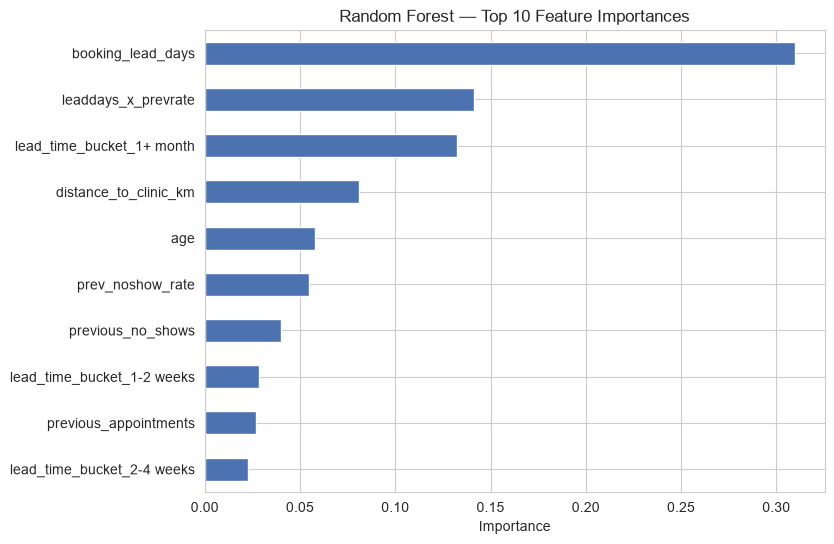

booking_lead_days             0.309919
leaddays_x_prevrate           0.141092
lead_time_bucket_1+ month     0.132583
distance_to_clinic_km         0.081137
age                           0.058101
prev_noshow_rate              0.054702
previous_no_shows             0.040215
lead_time_bucket_1-2 weeks    0.028722
previous_appointments         0.026738
lead_time_bucket_2-4 weeks    0.022459
dtype: float64

In [11]:
importances = pd.Series(rf.feature_importances_, index=X_train2.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).plot(kind="barh", color=COLORS[0])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest — Top 10 Feature Importances")
plt.savefig("../visuals/w6_04_feature_importance.png", bbox_inches="tight")
plt.show()

importances.head(10)

`booking_lead_days` still dominates, but the new `leaddays_x_prevrate` interaction feature ranks 2nd (~14% importance), confirming it captures real signal the error analysis pointed to. `distance_to_clinic_km` ranks surprisingly high (~8%) despite not being explored in depth in Week 5 — a candidate for the Data Analytics cross-track input (Section 8) to explain further (e.g. transport/geographic barriers).

Cross-Track Integration

Overall no-show rate: 0.512


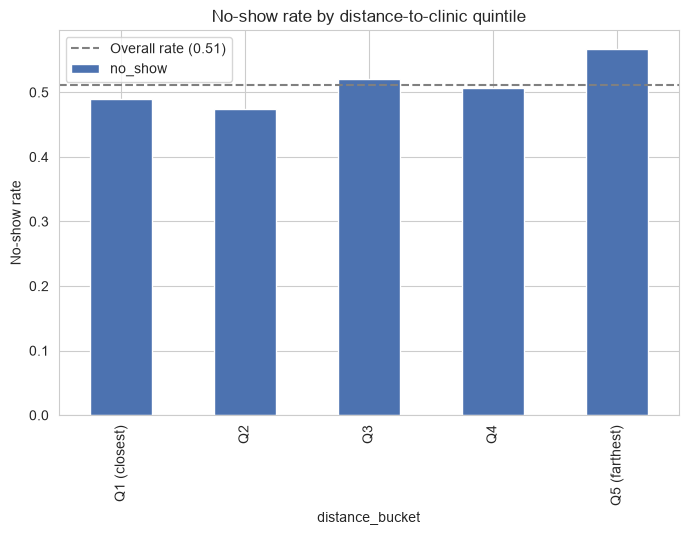

distance_bucket
Q1 (closest)     0.488982
Q2               0.474506
Q3               0.520964
Q4               0.505946
Q5 (farthest)    0.567797
Name: no_show, dtype: float64

In [12]:
overall_rate = df["no_show"].mean()
print(f"Overall no-show rate: {overall_rate:.3f}")

df["distance_bucket"] = pd.qcut(df["distance_to_clinic_km"], q=5,
                                 labels=["Q1 (closest)", "Q2", "Q3", "Q4", "Q5 (farthest)"])

dist_rates = df.groupby("distance_bucket", observed=True)["no_show"].mean()

plt.figure()
dist_rates.plot(kind="bar", color=COLORS[0])
plt.axhline(overall_rate, color="gray", linestyle="--", label=f"Overall rate ({overall_rate:.2f})")
plt.ylabel("No-show rate")
plt.title("No-show rate by distance-to-clinic quintile")
plt.legend()
plt.savefig("../visuals/w6_05_noshow_by_distance.png", bbox_inches="tight")
plt.show()

dist_rates

No-show rate rises from ~0.49 for the closest patients (Q1-Q2) to **0.57 for the farthest quintile (Q5)** — confirming `distance_to_clinic_km`'s importance in the model isn't spurious.

<Figure size 800x500 with 0 Axes>

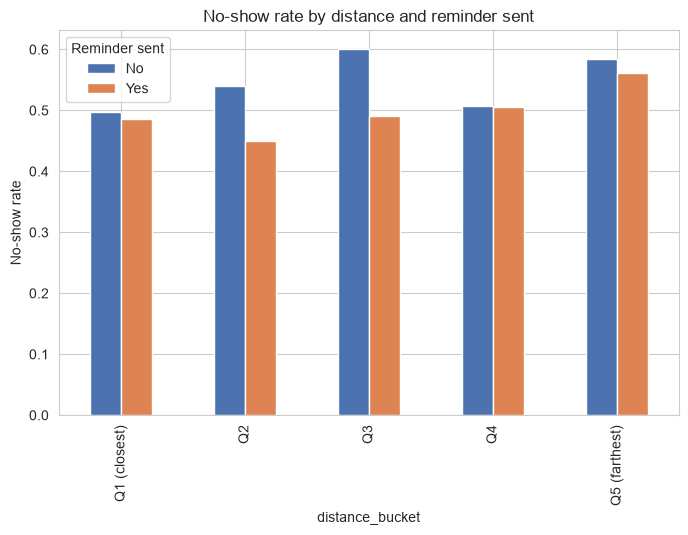

reminder_sent,No,Yes
distance_bucket,,
Q1 (closest),0.498024,0.485714
Q2,0.540230,0.450000
Q3,0.601533,0.490620
Q4,0.507692,0.505263
Q5 (farthest),0.584000,0.561960


In [13]:
reminder_by_distance = df.groupby(["distance_bucket", "reminder_sent"], observed=True)["no_show"].mean().unstack()

plt.figure()
reminder_by_distance.plot(kind="bar", color=COLORS)
plt.ylabel("No-show rate")
plt.title("No-show rate by distance and reminder sent")
plt.legend(title="Reminder sent")
plt.savefig("../visuals/w6_06_reminder_effect_by_distance.png", bbox_inches="tight")
plt.show()

reminder_by_distance

**Most actionable finding:** the reminder's effectiveness fades with distance. For mid-range patients (Q2-Q3), a reminder cuts the no-show rate by roughly 10 percentage points (e.g. Q3: 0.59 → 0.48). For the farthest patients (Q5), a reminder only reduces it by about 2 points (0.58 → 0.56). A simple SMS/WhatsApp nudge is not enough for patients far from the clinic — they likely need a different intervention (telehealth option, transport support, or a different scheduling approach) rather than just a reminder.

Day-of-week, time-of-day, and appointment-type effects were also checked but were much weaker (no-show rates ranging roughly 0.49-0.53 across all of them) and are not pursued further here.

In [14]:
df["far_and_reminded"] = ((df["distance_to_clinic_km"] >= df["distance_to_clinic_km"].quantile(0.8)) &
                           (df["reminder_sent"] == "Yes")).astype(int)

train_df3, test_df3 = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
X_train3 = train_df3.drop(columns=["patient_id", "no_show", "distance_bucket"])
y_train3 = train_df3["no_show"]
X_test3 = test_df3.drop(columns=["patient_id", "no_show", "distance_bucket"])
y_test3 = test_df3["no_show"]

X_train3 = pd.get_dummies(X_train3, drop_first=True)
X_test3 = pd.get_dummies(X_test3, drop_first=True)
X_test3 = X_test3.reindex(columns=X_train3.columns, fill_value=0)

rf3 = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                              random_state=42, class_weight="balanced")
rf3.fit(X_train3, y_train3)
pred_rf3 = rf3.predict(X_test3)
prob_rf3 = rf3.predict_proba(X_test3)[:, 1]

results_df.loc["Random Forest + far_and_reminded feature"] = evaluate(
    "Random Forest + far_and_reminded feature", y_test3, pred_rf3, prob_rf3
)
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline — Logistic Regression (Week 5),0.627,0.620,0.656,0.638,0.677
Logistic Regression + interaction feature,0.630,0.626,0.648,0.637,0.678
Random Forest,0.636,0.634,0.640,0.637,0.685
Gradient Boosting,0.629,0.625,0.646,0.635,0.677
Random Forest + far_and_reminded feature,0.638,0.638,0.636,0.637,0.684
